## Context 

E-Mart is a Chinese retailer that discovered the e-commerce as a way to sell to the entire world, rather than just to the population of their home city. The company has been growing without much worries, and now It wants to start using the data collected during its 4 years of e-commerce to keep growing and make more money.

Cycle 1 

The board of directors expects:

- A Dashboard with KPIs to track their growth.

- Robust Data Analysis, as well as recommendation of actions. What's the actionable based on your analysis?

- An Analysis about the countries, a segmentation by sales, profit and more. They need insights to help increasing revenue.

- **Sales forecast for the next year, in order to enable strategic planning.**

## Agenda 

[0.0 Imports](#0.0-Imports)<br>
&emsp;[0.1 Helper Functions](#0.1-Helper-Functions)<br>
&emsp;[0.2 Loading Data](#0.2-Loading-Data)<br>

[1.0 Moving Average Model](#1.0-Moving-Average-Model)<br>

[2.0 ARIMA](#2.0-ARIMA)<br>

[3.0 SARIMA](#3.0-SARIMA)<br>


&emsp;&emsp;[](#)<br>


## 0.0 Imports

In [1]:
from data_science_lib.dir import Directory, join_paths
from data_science_lib.graph import fig
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error # from data_science_lib.machine_learning import evaluate

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta 

from sklearn.model_selection import TimeSeriesSplit

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

%matplotlib inline

In [2]:
fig(set_as_global=True)

In [3]:
directory = Directory("pr_v01_sales_time_series_forecast", is_sub_project=True)

### 0.1 Helper Functions

In [4]:
def evaluate(y_true, y_pred, timeline_message=None, show_results=True):
    mae = mean_absolute_error(y_true, y_pred).round(2)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    if timeline_message:
        print(timeline_message)    
    if show_results:
        print(f'''On average, our predictions are {mape.round(2)}% above or below the real value.''')
        print(f'''Which means an error of about $ {"{:,.2f}".format(mae)}''')
    return mae, mape/100

### 0.2 Loading Data

In [5]:
df = pd.read_parquet(join_paths([directory.DATA_DIR, 'processed', 'e_mart_data.parquet']), columns=['order_date', 'sales'])
df.set_index('order_date', inplace=True)
df.head()

,sales
order_date,
2011-01-01,408.300
2011-01-01,120.366
2011-01-01,66.120
2011-01-01,44.865
2011-01-01,113.670


In [6]:
date_before_forecast = pd.to_datetime('2013-12-31')
date_to_forecast_begin= pd.to_datetime('2014-01-01')
year_ago = (pd.to_datetime(date_to_forecast_begin) - timedelta(days=365)).date()
date_to_forecast_end = (pd.to_datetime('2014-01-01') + timedelta(days=365)).date()

## 1.0 Moving Average Model

On average, our predictions are **15.45%** above or below the real value.<br>
Which means an error of about **$ 60,672.28**

In [7]:
monthly_series = df.resample('M').sum()

moving_avg defined by "pr_v01_sales_time_series_analysis.ipynb" file in:

    1.0 Decomposition
        1.1 Monthly

In [8]:
moving_avg = 12 # Tests: (ma=3, mape=15.7%) | (ma=4, mape=15.85%)
series = pd.concat([monthly_series, monthly_series.rolling(window=moving_avg).mean().shift(1)], axis=1).dropna()
# series.index = series.index.date
series.columns = ['sales', 'moving_average']
evaluate(series.loc[date_to_forecast_begin:, 'sales'], series.loc[date_to_forecast_begin:, 'moving_average']);

On average, our predictions are 15.45% above or below the real value.
Which means an error of about $ 60,672.28


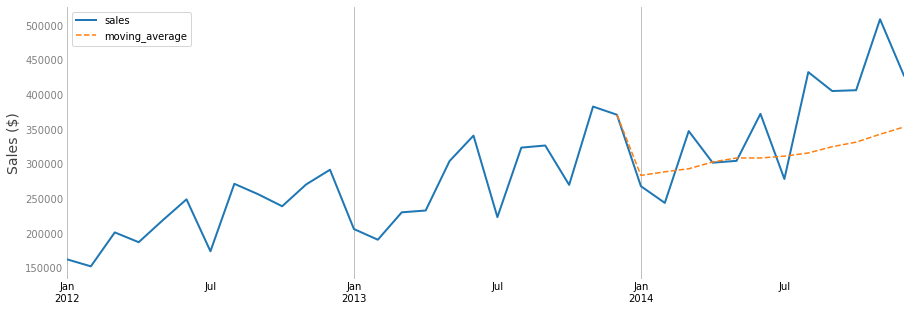

In [9]:
series['error'] = series['sales'] - series['moving_average']
series['absolute_error'] = series['error'].abs()
series['percentage_error'] = series['absolute_error'] / series['sales']

series.loc[:date_to_forecast_begin, 'moving_average'] = np.nan
series.loc[date_before_forecast :date_to_forecast_begin, ['moving_average']] = series.loc[date_before_forecast:date_to_forecast_begin, ['sales']].values

series['sales'].plot(linewidth=2)
series['moving_average'].plot(style='--', color='#ff7f0e')

plt.box(False)
plt.grid(axis='x')
plt.legend()
plt.tick_params(axis='both', which='both', length=0)
plt.ylabel("Sales ($)", size=14, color='#424242')
plt.xlabel(None)
plt.yticks(color='grey');

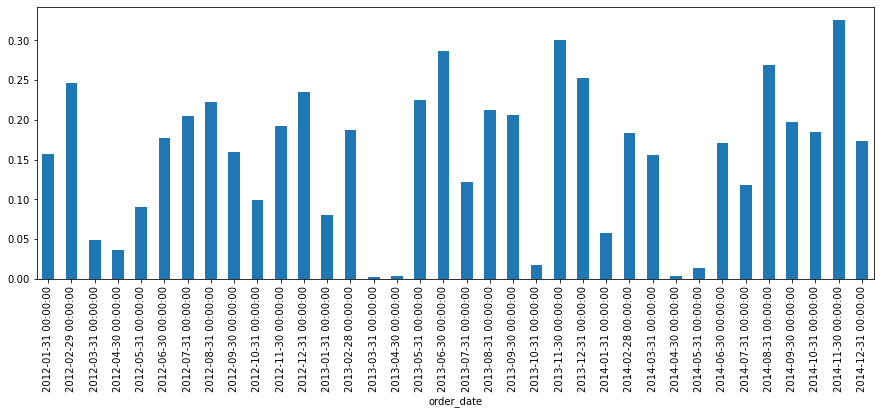

In [10]:
series['percentage_error'].plot.bar();

In [11]:
series.loc[date_to_forecast_begin:]

,sales,moving_average,error,absolute_error,percentage_error
order_date,,,,,
2014-01-31,268265.52240,283812.204115,-15546.681715,15546.681715,0.057953
2014-02-28,244159.30486,288962.731330,-44803.426470,44803.426470,0.183501
2014-03-31,347720.96868,293387.442388,54333.526292,54333.526292,0.156256
2014-04-30,302132.54000,303151.873555,-1019.333555,1019.333555,0.003374
2014-05-31,304798.83604,308897.806185,-4098.970145,4098.970145,0.013448
2014-06-30,372577.23298,308921.878908,63655.354072,63655.354072,0.170851
2014-07-31,278672.17326,311539.786348,-32867.613088,32867.613088,0.117944
2014-08-31,432731.04194,316125.579400,116605.462540,116605.462540,0.269464
2014-09-30,405436.70584,325196.782298,80239.923542,80239.923542,0.197910


## 2.0 ARIMA

On average, our predictions are **13.45%** above or below the real value.<br>
Which means an error of about **$ 41,857.92**

In [12]:
evaluation = monthly_series.copy()
evaluation['arima'] = np.nan
training = evaluation.loc[:date_to_forecast_begin]
# evaluation.loc[date_to_forecast_begin:date_to_forecast_end]

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\base\model.py:566: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


On average, our predictions are 13.45% above or below the real value.
Which means an error of about $ 41,857.92


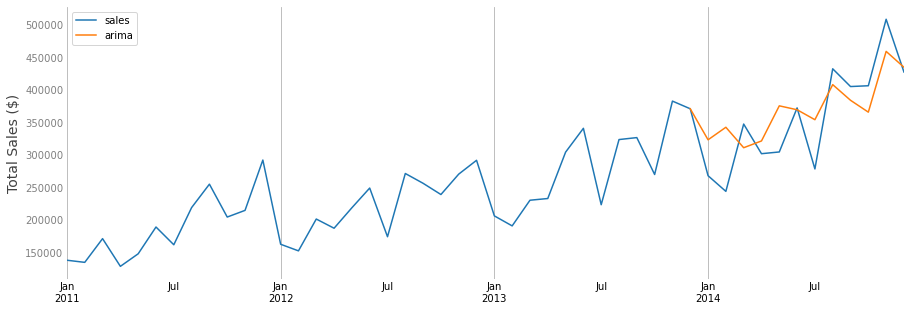

In [13]:
ar=12; i=1; ma=4
model = ARIMA(training['sales'].values, order=(ar,i,ma)).fit()
prediction = model.forecast(12)
evaluation.loc[date_to_forecast_begin:date_to_forecast_end, ['arima']] = prediction
evaluation.loc[date_before_forecast:date_to_forecast_begin, ['arima']] = evaluation.loc[date_before_forecast:date_to_forecast_begin, ['sales']].values
evaluation.loc[:date_to_forecast_end].plot()
plt.ylabel("Total Sales ($)", size=14, color='#424242')
plt.xlabel(None)
plt.box(False)
plt.grid(axis='x')
plt.legend()
plt.tick_params(axis='both', which='both', length=0)
plt.yticks(color='grey');

evaluate(evaluation.loc[date_to_forecast_begin:, 'sales'], evaluation.loc[date_to_forecast_begin:, 'arima']);

In [14]:
# evaluation['error'] = evaluation['sales'] - evaluation['arima']
# evaluation['absolute_error'] = evaluation['error'].abs()
# evaluation['percentage_error'] = evaluation['absolute_error'] / evaluation['sales']
# evaluation

## 3.0 SARIMA

On average, our predictions are **8.64%** above or below the real value.<br>
Which means an error of about **$ 31,639.14**

On average, our predictions are 8.64% above or below the real value.
Which means an error of about $ 31,639.14


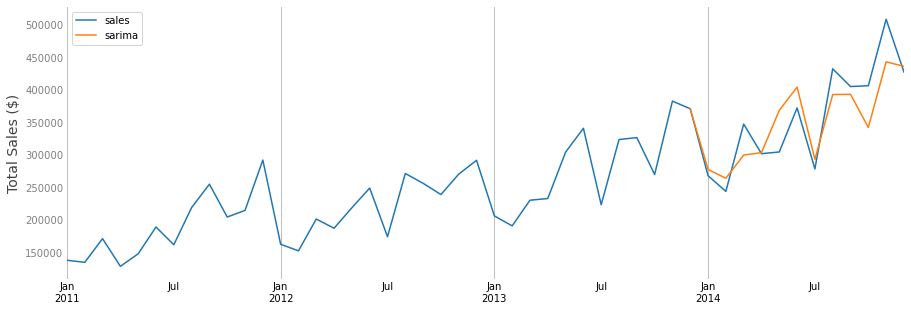

In [15]:
ar=1; i=1; ma=4
model = SARIMAX(training['sales'].values, order=(ar,i,ma), seasonal_order=(1,1,0,12)).fit()
prediction = model.forecast(12)
evaluation.loc[date_to_forecast_begin:date_to_forecast_end, ['sarima']] = prediction
evaluation.loc[date_before_forecast:date_to_forecast_begin, ['sarima']] = evaluation.loc[date_before_forecast:date_to_forecast_begin, ['sales']].values

evaluation.loc[:date_to_forecast_end, ['sales','sarima']].plot()
plt.ylabel("Total Sales ($)", size=14, color='#424242')
plt.xlabel(None)
plt.box(False)
plt.grid(axis='x')
plt.legend()
plt.tick_params(axis='both', which='both', length=0)
plt.yticks(color='grey');


evaluate(evaluation.loc[date_to_forecast_begin:, 'sales'], evaluation.loc[date_to_forecast_begin:, 'sarima']);

In [16]:
evaluation['error'] = evaluation['sales'] - evaluation['sarima']
evaluation['absolute_error'] = evaluation['error'].abs()
evaluation['percentage_error'] = evaluation['absolute_error'] / evaluation['sales']
evaluation.loc[date_to_forecast_begin:]

,sales,arima,sarima,error,absolute_error,percentage_error
order_date,,,,,,
2014-01-31,268265.52240,323500.652582,277843.105377,-9577.582977,9577.582977,0.035702
2014-02-28,244159.30486,342789.799080,264322.381208,-20163.076348,20163.076348,0.082582
2014-03-31,347720.96868,311316.153293,300036.584821,47684.383859,47684.383859,0.137134
2014-04-30,302132.54000,321731.899873,303726.569329,-1594.029329,1594.029329,0.005276
2014-05-31,304798.83604,375763.762710,368796.626541,-63997.790501,63997.790501,0.209967
2014-06-30,372577.23298,369735.494346,404569.683381,-31992.450401,31992.450401,0.085868
2014-07-31,278672.17326,354419.879849,293298.766714,-14626.593454,14626.593454,0.052487
2014-08-31,432731.04194,408366.924115,393099.293630,39631.748310,39631.748310,0.091585
2014-09-30,405436.70584,384292.008233,393460.663859,11976.041981,11976.041981,0.029539


## 2015 Forecast

In [17]:
model = SARIMAX(monthly_series.values, order=(ar,i,ma), seasonal_order=(1,1,0,12)).fit()
predictions = model.forecast(12)

In [18]:
idx_2015 = monthly_series.loc[date_to_forecast_begin:].reset_index()['order_date'].apply(lambda x: str(x).replace('2014', '2015'))
idx_2015 = pd.to_datetime(idx_2015)
indexes = monthly_series.index.append(pd.Index(idx_2015))
sales = monthly_series['sales'].append(pd.Series(predictions)).values

In [19]:
sales = pd.DataFrame(sales, columns=['sales'], index=indexes)
sales['sales_2015'] = sales['sales']
sales.loc[:date_to_forecast_end, ['sales_2015']] = np.nan
sales.loc[date_to_forecast_end:, ['sales']] = np.nan
sales.loc['2014-12-31', 'sales_2015'] = sales.loc['2014-12-31', 'sales']

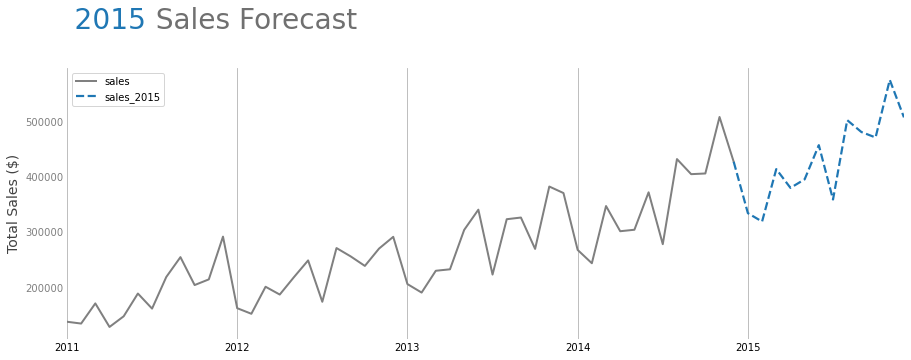

In [20]:
sales['sales'].plot(linewidth=2, color='grey')
sales['sales_2015'].plot(linewidth=2.2, style='--')
plt.title(f"          Sales Forecast\n", fontsize=28, color='#707070', loc='left')
plt.text(490, 609000, "    2015\n", color='#1f77b4', size=28);

plt.ylabel("Total Sales ($)", size=14, color='#424242')
plt.xlabel(None)
plt.box(False)
plt.grid(axis='x')
plt.legend()
plt.tick_params(axis='both', which='both', length=0)
plt.yticks(color='grey');

In [21]:
mae, mape = evaluate(evaluation.loc[date_to_forecast_begin:, 'sales'], evaluation.loc[date_to_forecast_begin:, 'sarima']);

On average, our predictions are 8.64% above or below the real value.
Which means an error of about $ 31,639.14


In [22]:
sales.loc['2015-01-31':, ['min_estimate']] = (sales.loc['2015-01-31':, ['sales_2015']] / (1 + mape)).values
sales.loc['2015-01-31':, ['max_estimate']] = (sales.loc['2015-01-31':, ['sales_2015']] / (1 - mape)).values

In [23]:
sales.loc['2015-01-31':].to_csv(
    join_paths([directory.DATA_DIR, 'processed', 'dashboard', 'sales_forecast_2015.csv']))

In [24]:
sales.loc['2014-12-31', 'min_estimate'] = sales.loc['2014-12-31', 'sales']
sales.loc['2014-12-31', 'max_estimate'] = sales.loc['2014-12-31', 'sales']

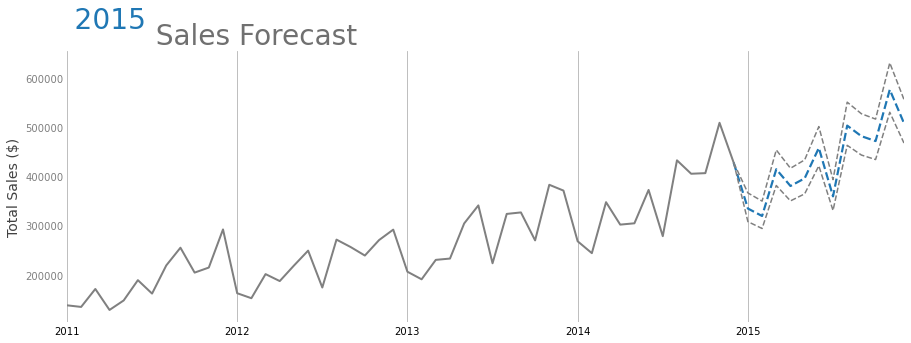

In [25]:
sales['sales'].plot(linewidth=2, color='grey')
sales['sales_2015'].plot(linewidth=2.2, style='--') # , color='white'
sales['min_estimate'].plot(linewidth=1.5, style='--', color='grey')
sales['max_estimate'].plot(linewidth=1.5, style='--', color='grey')

plt.title(f"          Sales Forecast", fontsize=28, color='#707070', loc='left')
plt.text(490, 634900, "    2015\n", color='#1f77b4', size=28);

plt.ylabel("Total Sales ($)", size=14, color='#424242')
plt.xlabel(None)
plt.box(False)
plt.grid(axis='x')
# plt.legend()
plt.tick_params(axis='both', which='both', length=0)
plt.yticks(color='grey');

### Error Test

Error Interval = mape + cumulative( std(mape)/period ) 

        mape = 8.64%
        std(mape) = 6.22%
        
        We add 0.51% times period for each month
        
            Error
        Jan 8.64%
        Feb 9.15%
        Mar 9.67%
        Apr 10.2%

In [66]:
round(    8.64 + (0.5189 * 1)    ,2),\
round(    8.64 + (0.5189 * 2)    ,2),\
round(    8.64 + (0.5189 * 3)    ,2),\
round(    8.64 + (0.5189 * 4)    ,2)

(9.16, 9.68, 10.2, 10.72)

In [26]:
mape = pd.DataFrame([0.0864]*12, columns=['mape'])
mape.index = evaluation.loc[date_to_forecast_begin:, 'percentage_error'].index
mape.T

order_date,2014-01-31,2014-02-28,2014-03-31,2014-04-30,2014-05-31,2014-06-30,2014-07-31,2014-08-31,2014-09-30,2014-10-31,2014-11-30,2014-12-31
mape,0.0864,0.0864,0.0864,0.0864,0.0864,0.0864,0.0864,0.0864,0.0864,0.0864,0.0864,0.0864


In [27]:
std12 = evaluation.loc[date_to_forecast_begin:, 'percentage_error'].std()/12
std = 0
for date in evaluation.loc[date_to_forecast_begin:, 'percentage_error'].index:
    mape.loc[date, 'mape'] = mape.loc[date, 'mape'] + std
    std += std12

In [28]:
mape.index = sales.loc['2015-01-31':, ['min_estimate']].index
mape.T

order_date,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,2015-06-30,2015-07-31,2015-08-31,2015-09-30,2015-10-31,2015-11-30,2015-12-31
mape,0.0864,0.09159,0.096779,0.101969,0.107159,0.112348,0.117538,0.122728,0.127917,0.133107,0.138297,0.143486


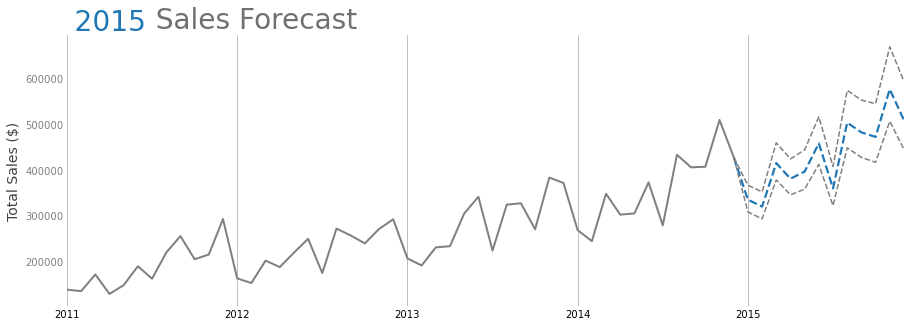

In [31]:
sales.loc['2015-01-31':, ['min_estimate']] = (sales.loc['2015-01-31':, ['sales_2015']].values / (1 + mape[['mape']])).values
sales.loc['2015-01-31':, ['max_estimate']] = (sales.loc['2015-01-31':, ['sales_2015']].values / (1 - mape[['mape']])).values

sales['sales'].plot(linewidth=2, color='grey')
sales['sales_2015'].plot(linewidth=2.2, style='--') # , color='white'
sales['min_estimate'].plot(linewidth=1.5, style='--', color='grey')
sales['max_estimate'].plot(linewidth=1.5, style='--', color='grey')

plt.title(f"          Sales Forecast", fontsize=28, color='#707070', loc='left')
plt.text(490, 634900, "    2015\n", color='#1f77b4', size=28);

plt.ylabel("Total Sales ($)", size=14, color='#424242')
plt.xlabel(None)
plt.box(False)
plt.grid(axis='x')
# plt.legend()
plt.tick_params(axis='both', which='both', length=0)
plt.yticks(color='grey');

## 2014

In [35]:
evaluation.loc[date_to_forecast_begin:date_to_forecast_end, ['min_estimate']] = (evaluation.loc[date_to_forecast_begin:date_to_forecast_end, ['sarima']].values / (1 + mape[['mape']])).values
evaluation.loc[date_to_forecast_begin:date_to_forecast_end, ['max_estimate']] = (evaluation.loc[date_to_forecast_begin:date_to_forecast_end, ['sarima']].values / (1 - mape[['mape']])).values

On average, our predictions are 8.64% above or below the real value.
Which means an error of about $ 31,639.14


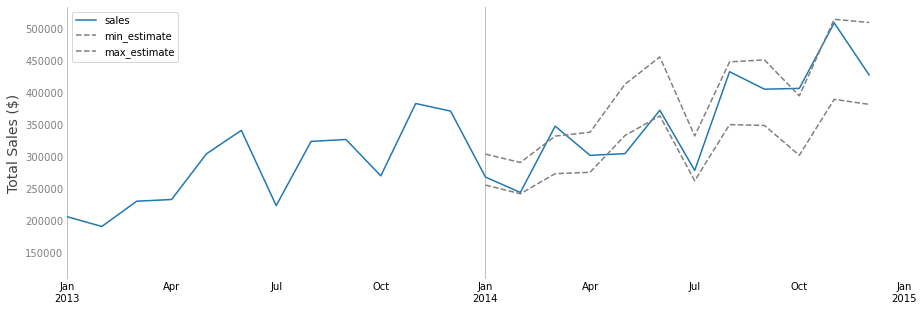

In [107]:
ar=1; i=1; ma=4
model = SARIMAX(training['sales'].values, order=(ar,i,ma), seasonal_order=(1,1,0,12)).fit()
prediction = model.forecast(12)
evaluation.loc[date_to_forecast_begin:date_to_forecast_end, ['sarima']] = prediction
evaluation.loc[date_before_forecast:date_to_forecast_begin, ['sarima']] = evaluation.loc[date_before_forecast:date_to_forecast_begin, ['sales']].values

evaluation.loc[:date_to_forecast_end, ['sales']].plot()
evaluation['min_estimate'].plot(linewidth=1.5, style='--', color='grey')
evaluation['max_estimate'].plot(linewidth=1.5, style='--', color='grey')
plt.ylabel("Total Sales ($)", size=14, color='#424242')
plt.xlabel(None)
plt.box(False)
plt.grid(axis='x')
plt.legend()
plt.tick_params(axis='both', which='both', length=0)
plt.yticks(color='grey');
plt.xlim('2013-1-1','2015-1-1')

evaluate(evaluation.loc[date_to_forecast_begin:, 'sales'], evaluation.loc[date_to_forecast_begin:, 'sarima']);